In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
heritability = pd.read_csv("/neurospin/dico/adufournet/2026_Nature/images/globalheritability_table.csv")
heritability = heritability[["region", "SNP-based h²"]]
heritability

,region,SNP-based h²
0,SCall-SsP-SintraCing_left,0.259414
1,SCall_left,0.232730
2,FPO-SCu-ScCal_right,0.231334
3,FPO-SCu-ScCal_left,0.229071
4,SCall-SsP-SintraCing_right,0.213493
5,ScCal-SLi_right,0.212530
6,SCall_right,0.211159
7,FCLp-subsc-FCLa-INSULA_left,0.199832
8,ScCal-SLi_left,0.197606
9,FColl-SRh_left,0.191904


https://www.sciencedirect.com/science/article/pii/S1053811922007443

https://onlinelibrary.wiley.com/doi/epdf/10.1002/ana.410010109

In [62]:
dic_chrono = {
 'SCall-SsP-SintraCing_left':(16+(24.82+23.94)/2)/2,
 'SCall-SsP-SintraCing_right':(16+(24.82+24.49)/2)/2,

 'SCall_left':14,
 'SCall_right':14,

 'FPO-SCu-ScCal_left':16,
 'FPO-SCu-ScCal_right':16,

 'ScCal-SLi_left':np.nan,
 'ScCal-SLi_right':np.nan,

 'FColl-SRh_left':23,
 'FColl-SRh_right':23,

 'FCLp-subsc-FCLa-INSULA_left':np.nan,
 'FCLp-subsc-FCLa-INSULA_right':np.nan,

 'STi-SOTlat_left':(26.94+26.89+28.42+28.92)/4,
 'STi-SOTlat_right':(26.58+25.50+27.65+27.96)/4,

 'SC-sylv_left':24.27,
 'SC-sylv_right':23.99,

 'Lobule_parietal_sup_left':np.nan,
 'Lobule_parietal_sup_right':np.nan,

 'SC-SPoC_left':(25.45+24.27)/2,
 'SC-SPoC_right':(23.99+25.15)/2,

 'SsP-SPaint_left':(24.82+23.94)/2,
 'SsP-SPaint_right':(24.82+24.49)/2,

 'FIP-FIPPoCinf_left':(24.96+25.5)/2,
 'FIP-FIPPoCinf_right':(24.97+25.39)/2,

 'SOr_left':(25.11+25.79)/2,
 'SOr_right':(25.85+25.21)/2,

 'STi-STs-STpol_left':((25.11+24.00)/2 + (26.94+26.89)/2)/2,
 'STi-STs-STpol_right':((24.30+22.95)/2 + (26.58+25.50)/2)/2,

 'SOr-SOlf_left':np.nan,
 'SOr-SOlf_right':np.nan,

 'OCCIPITAL_left':(28.42+28.92)/2,
 'OCCIPITAL_right':(27.65+27.96)/2,

 'STs_left':(25.11+24.00)/2,
 'STs_right':(24.30+22.95)/2,

 'SPoC_left':25.45,
 'SPoC_right':25.15,
 
 'STsbr_left':np.nan,
 'STsbr_right':np.nan,

 'SFinf-BROCA-SPeCinf_left':np.nan,
 'SFinf-BROCA-SPeCinf_right':np.nan,

 'SC-SPeC_left':(24.67+24.27)/2,
 'SC-SPeC_right':(24.72+23.99)/2,

 'FCMpost-SpC_left':np.nan,
 'FCMpost-SpC_right':np.nan,

 'SPeC_left':24.67,
 'SPeC_right':24.72,

 'SFmarginal-SFinfant_left':np.nan,
 'SFmarginal-SFinfant_right':np.nan,

 'SFint-FCMant_left':(24.77+25.47)/2,
 'SFint-FCMant_right':(25.31+24.90)/2,

 'SFinter-SFsup_left':(26.21+26.59)/2,
 'SFinter-SFsup_right':(26.59+26.46)/2,

 'SFint-SR_left':(24.77+25.47)/2,
 'SFint-SR_right':(25.31+24.90)/2,

 'SFmedian-SFpoltr-SFsup_left':(28.64+29.49)/2,
 'SFmedian-SFpoltr-SFsup_right':(28.49+29.71)/2}

In [63]:
list_region = []
list_time = []
for region, value in dic_chrono.items():
    list_region.append(region)
    list_time.append(value)


time_df = pd.DataFrame({"region":list_region, "time":list_time})
merged_df = pd.merge(heritability, time_df, on='region')
merged_df.corr()

,SNP-based h²,time
SNP-based h²,1.000000,-0.729887
time,-0.729887,1.000000


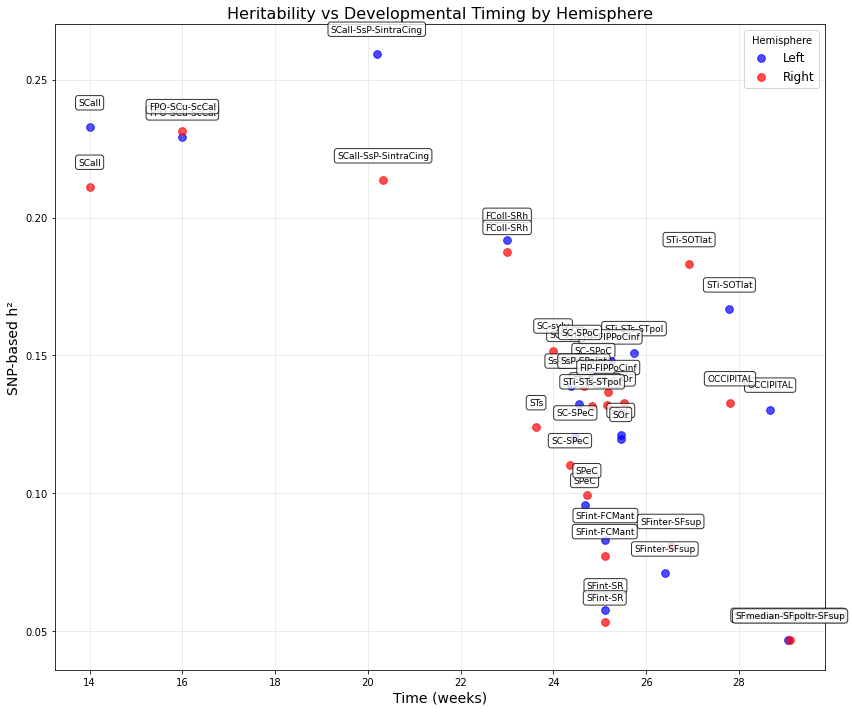

In [64]:
# Add hemisphere column
merged_df['hemisphere'] = merged_df['region'].apply(lambda x: 'left' if x.endswith('_left') else 'right')

# Colors for hemispheres
colors = {'left': 'blue', 'right': 'red'}

# Create the scatter plot
plt.figure(figsize=(12, 10))  # Larger figure for publication

for hemi in ['left', 'right']:
    subset = merged_df[merged_df['hemisphere'] == hemi]
    plt.scatter(subset["time"], subset["SNP-based h²"], color=colors[hemi], label=hemi.capitalize(), s=60, alpha=0.7)
    
    # Add region labels with lines
    for idx, row in subset.iterrows():
        if row['region'].endswith('_right') or row['region'].endswith('_left'):
            plt.annotate(row['region'].replace('_right', '').replace('_left', ''), 
                        xy=(row['time'], row['SNP-based h²']), 
                        xytext=(0, 20), textcoords='offset points',
                        fontsize=9, ha='center', va='bottom', 
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8),)
                        # arrowprops=dict(arrowstyle='-', color='gray', alpha=0.7, shrinkA=5, shrinkB=0))

plt.xlabel("Time (weeks)", fontsize=14)
plt.ylabel("SNP-based h²", fontsize=14)
plt.title("Heritability vs Developmental Timing by Hemisphere", fontsize=16)
plt.legend(title="Hemisphere", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save the figure for publication
plt.savefig('/volatile/ad279118/2024_adufournet_sulcus_genetics/notebooks/Report/heritability_vs_timing.png', dpi=300, bbox_inches='tight')

plt.show()